# Validación del conjunto de datos para clasificación CNN

Este notebook tiene como finalidad validar las características del conjunto de datos preparado para la etapa de clasificación binaria de tumores ováricos mediante arquitecturas CNN.

In [2]:
# importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np

## 1. Configuración de rutas

El conjunto de datos utilizado corresponde al conjunto experimental generado previamente para las etapas de segmentación y clasificación.

In [3]:
PROJECT_DIR = Path("../..")
CSV_PATH = (PROJECT_DIR / "configs" / "splits" / "mmotu_experimental_split_standard.csv")
DATA_DIR = (PROJECT_DIR / "data" / "processed" / "MMOTU_OTU_2D_experimental")

print("CSV:", CSV_PATH)
print("Dataset:", DATA_DIR)

CSV: ../../configs/splits/mmotu_experimental_split_standard.csv
Dataset: ../../data/processed/MMOTU_OTU_2D_experimental


In [4]:
df = pd.read_csv(CSV_PATH)
df.head()

,image_id,image_name,source_split,original_class,binary_label,binary_class,experimental_split
0,789,789.JPG,train,5,0,benign,train
1,312,312.JPG,train,4,0,benign,train
2,1196,1196.JPG,train,6,1,malignant,train
3,297,297.JPG,train,1,0,benign,train
4,263,263.JPG,train,2,0,benign,train


## 2. Inspección del manifiesto experimental

El manifiesto experimental contiene la información necesaria para establecer la relación entre cada imagen ecográfica y su etiqueta de clasificación.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469 entries, 0 to 1468
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   image_id            1469 non-null   int64 
 1   image_name          1469 non-null   object
 2   source_split        1469 non-null   object
 3   original_class      1469 non-null   int64 
 4   binary_label        1469 non-null   int64 
 5   binary_class        1469 non-null   object
 6   experimental_split  1469 non-null   object
dtypes: int64(3), object(4)
memory usage: 80.5+ KB


In [6]:
df.columns.tolist()

['image_id',
 'image_name',
 'source_split',
 'original_class',
 'binary_label',
 'binary_class',
 'experimental_split']

## 3. Distribución de clases

Debido a que el problema corresponde a la clasificación binaria de tumores ováricos, se analiza la distribución de muestras entre las clases benignas y malignas.

In [7]:
class_distribution = (df["binary_class"].value_counts())
class_distribution

binary_class
benign       1312
malignant     157
Name: count, dtype: int64

In [8]:
class_percentage = (df["binary_class"].value_counts(normalize=True).mul(100).round(2))
class_percentage

binary_class
benign       89.31
malignant    10.69
Name: proportion, dtype: float64

Esta diferencia será considerada durante la definición de la estrategia de entrenamiento y la selección de métricas de evaluación.

## 4. Distribución de clases por partición del conjunto de datos

Se analiza la distribución de clases en los conjuntos destinados al entrenamiento, validación y prueba.

In [9]:
split_class_distribution = pd.crosstab(df["experimental_split"], df["binary_class"])
split_class_distribution

binary_class,benign,malignant
experimental_split,,
test,421,48
train,713,87
validation,178,22


## 5. Distribución porcentual de clases por partición

Además de la cantidad absoluta de muestras, se calcula la proporción de cada clase dentro de los conjuntos de entrenamiento, validación y prueba.

In [10]:
split_percentage = (
    pd.crosstab(
        df["experimental_split"],
        df["binary_class"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

split_percentage

binary_class,benign,malignant
experimental_split,,
test,89.77,10.23
train,89.12,10.88
validation,89.00,11.00


## 6. Verificación de correspondencia entre registros e imágenes

Se verifica que todas las muestras registradas en el manifiesto experimental tengan asociada una imagen física dentro de la estructura organizada del conjunto de datos.

In [11]:
split_mapping = {
    "train": "train",
    "validation": "validation",
    "test": "test"
}
split_mapping

{'train': 'train', 'validation': 'validation', 'test': 'test'}

In [12]:
missing_images = []

for _, row in df.iterrows():
    split_folder = split_mapping[row["experimental_split"]]
    image_path = (DATA_DIR / split_folder / "images" / row["image_name"])

    if not image_path.exists():
        missing_images.append(row["image_name"])

print("Cantidad de imágenes faltantes:", len(missing_images))

Cantidad de imágenes faltantes: 0


## 7. Conteo de imágenes físicas por partición

Se compara la cantidad de imágenes registradas en el manifiesto experimental con la cantidad de archivos disponibles en cada directorio físico.

In [13]:
physical_counts = {}

for split in ["train", "validation", "test"]:
    images_dir = (DATA_DIR / split / "images")
    count = len(list(images_dir.glob("*.JPG")))
    physical_counts[split] = count

physical_counts

{'train': 800, 'validation': 200, 'test': 469}

In [14]:
csv_counts = (df["experimental_split"].value_counts())
csv_counts

experimental_split
train         800
test          469
validation    200
Name: count, dtype: int64

## 8. Caracterización técnica de las imágenes ecográficas

Antes del entrenamiento de las arquitecturas CNN, se inspeccionan las características técnicas de las imágenes originales almacenadas en el conjunto experimental.

In [15]:
sample_images = df.sample(10, random_state=42)

for _, row in sample_images.iterrows():

    split_folder = row["experimental_split"]
    image_path = (DATA_DIR / split_folder / "images" / row["image_name"])
    img = Image.open(image_path)

    print(f"{row['image_name']} | " f"tamaño: {img.size} | " f"modo: {img.mode}")

325.JPG | tamaño: (1088, 607) | modo: RGB
891.JPG | tamaño: (479, 528) | modo: RGB
517.JPG | tamaño: (957, 542) | modo: RGB
1040.JPG | tamaño: (958, 527) | modo: RGB
579.JPG | tamaño: (476, 553) | modo: RGB
1330.JPG | tamaño: (482, 555) | modo: RGB
319.JPG | tamaño: (482, 534) | modo: RGB
305.JPG | tamaño: (477, 531) | modo: RGB
545.JPG | tamaño: (958, 556) | modo: RGB
1394.JPG | tamaño: (571, 590) | modo: RGB


## 9. Distribución de dimensiones originales

Debido a que las imágenes ecográficas fueron almacenadas conservando sus dimensiones originales, se analiza la variabilidad espacial del conjunto de datos.

In [16]:
image_sizes = []

for _, row in df.iterrows():

    image_path = (
        DATA_DIR /
        row["experimental_split"] /
        "images" /
        row["image_name"]
    )

    img = Image.open(image_path)

    image_sizes.append(
        img.size
    )


sizes_df = pd.DataFrame(
    image_sizes,
    columns=["width", "height"]
)

sizes_df.head()

,width,height
0,860,622
1,479,532
2,958,534
3,958,531
4,480,532


In [17]:
sizes_df.describe()

,width,height
count,1469.000000,1469.000000
mean,762.044248,550.841389
std,238.140675,55.400880
min,302.000000,266.000000
25%,481.000000,532.000000
50%,948.000000,537.000000
75%,959.000000,571.000000
max,1135.000000,794.000000


In [18]:
channel_modes = {}

for _, row in df.sample(100, random_state=42).iterrows():

    image_path = (
        DATA_DIR /
        row["experimental_split"] /
        "images" /
        row["image_name"]
    )

    mode = Image.open(image_path).mode

    channel_modes[mode] = (
        channel_modes.get(mode,0)+1
    )

channel_modes

{'RGB': 100}

## 10. Análisis de relación de aspecto

Debido a que las imágenes ecográficas presentan dimensiones originales variables, se analiza la relación entre ancho y alto de cada muestra.

In [19]:
aspect_ratios = (
    sizes_df["width"] /
    sizes_df["height"]
)

aspect_ratios.describe()

count    1469.000000
mean        1.390523
std         0.430415
min         0.721386
25%         0.905838
50%         1.555735
75%         1.795886
max         2.104283
dtype: float64

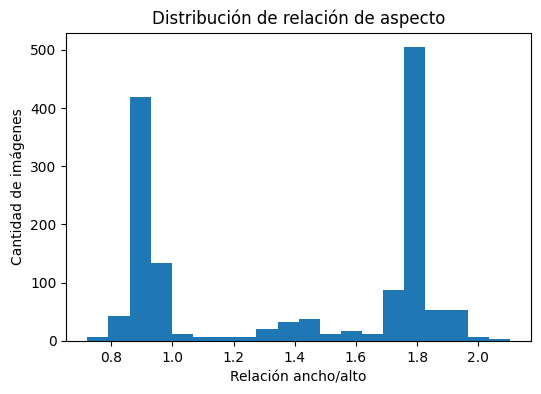

In [20]:
plt.figure(figsize=(6,4))

plt.hist(
    aspect_ratios,
    bins=20
)

plt.xlabel("Relación ancho/alto")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de relación de aspecto")

plt.show()

## Interpretación de la relación de aspecto

El análisis evidencia una variabilidad significativa en la relación entre ancho y alto de las imágenes ecográficas. La distribución presenta grupos diferenciados alrededor de relaciones cercanas a 0.9 y 1.8, indicando la presencia de muestras con diferentes proporciones espaciales.

Debido a esta variabilidad, una transformación mediante redimensionamiento directo hacia una dimensión cuadrada podría introducir distorsiones geométricas en la representación de las estructuras observadas.

Por ello, la estrategia de adaptación espacial deberá considerar la preservación de la relación de aspecto original durante la transformación de entrada hacia las arquitecturas CNN.